# Modelo de Regresion Logistica
## Clasificacion de Productividad Alta del Suelo
### Dataset: `suelos_regresion_logistica.csv`
---

## 1. Carga de Datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

BASE = r'C:\Users\ivanq\Desktop\Talento tech\trabajo final'
df = pd.read_csv('suelos_regresion_logistica.csv')
print(f'Dimensiones: {df.shape}')
print(f'Distribucion target:\n{df["prod_alta"].value_counts().to_string()}')
df.head(3)

Dimensiones: (29019, 351)
Distribucion target:
prod_alta
1    18142
0    10877


,pH,MO,fosforo,azufre,calcio,magnesio,potasio,CIC,CE,anios_est,...,riego_Goteo,riego_Goteo - Gravedad,riego_Gravedad,riego_Manguera,riego_No Tiene,riego_Por Inundaciã³N,riego_Superficial,riego_Superficial - Goteo,riego_Superficial - Inundaciã³N,riego_Superficial-Aspersiã³N
0,5.64,3.889,6.482,8.384,1.541,0.380,0.118,2.094,0.133,0.5,...,False,False,False,False,False,False,False,False,False,False
1,4.24,2.287,520.100,90.300,2.932,0.925,2.131,8.054,2.749,3.0,...,False,False,False,False,True,False,False,False,False,False
2,5.22,2.518,58.110,2.686,3.818,1.110,0.045,5.985,0.328,0.5,...,False,False,False,False,True,False,False,False,False,False


## 2. Analisis Exploratorio

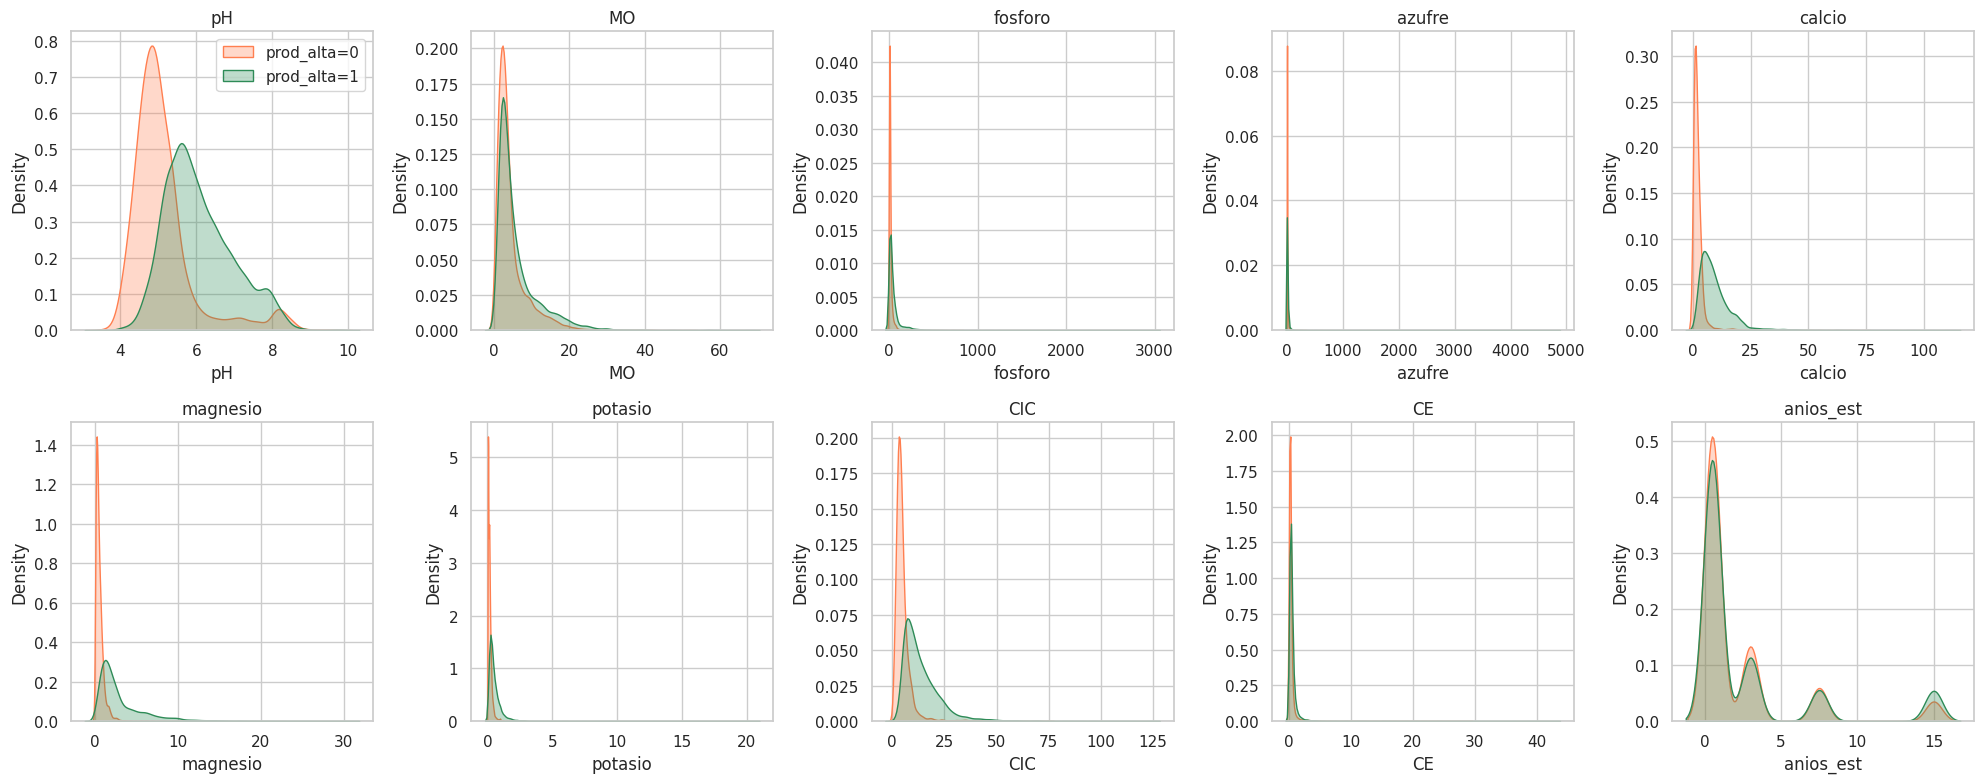

In [3]:
feats = ['pH','MO','fosforo','azufre','calcio','magnesio','potasio','CIC','CE','anios_est']
fig, axes = plt.subplots(2, 5, figsize=(20,8))
for i, f in enumerate(feats):
    ax = axes[i//5, i%5]
    for label, color in [(0, 'coral'), (1, 'seagreen')]:
        subset = df[df['prod_alta']==label][f].dropna()
        sns.kdeplot(subset, ax=ax, color=color, label=f'prod_alta={label}', fill=True, alpha=0.3)
    ax.set_title(f)
    if i==0: ax.legend()
plt.tight_layout(); plt.show()

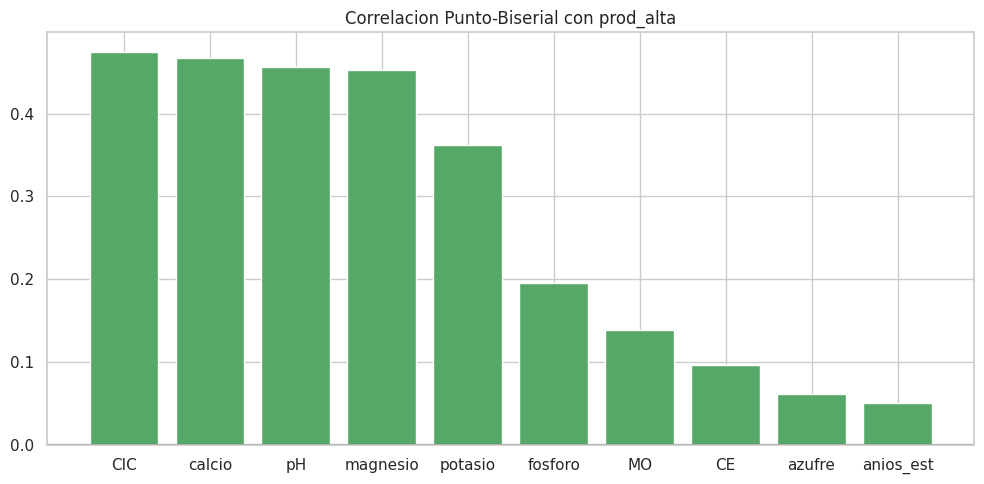

CIC: 0.4744
calcio: 0.4677
pH: 0.4568
magnesio: 0.4531
potasio: 0.3617
fosforo: 0.1949
MO: 0.1388
CE: 0.0962
azufre: 0.0614
anios_est: 0.0505


In [4]:
# Correlacion con target binario
from scipy.stats import pointbiserialr
corrs = [(f, pointbiserialr(df[f].fillna(df[f].median()), df['prod_alta'])[0]) for f in feats]
corrs.sort(key=lambda x: abs(x[1]), reverse=True)
plt.figure(figsize=(10,5))
colors = ['g' if c>0 else 'r' for _,c in corrs]
plt.bar([x[0] for x in corrs], [x[1] for x in corrs], color=colors)
plt.title('Correlacion Punto-Biserial con prod_alta')
plt.axhline(0, color='k'); plt.tight_layout(); plt.show()
for f, c in corrs: print(f'{f}: {c:.4f}')

## 3. Preparacion de Datos

In [8]:
X = df.drop(columns=['prod_alta']); y = df['prod_alta']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 1: Convert all columns that are currently 'bool' dtype to int (0/1)
for col in X_train.select_dtypes(include='bool').columns:
    X_train[col] = X_train[col].astype(int)
for col in X_test.select_dtypes(include='bool').columns:
    X_test[col] = X_test[col].astype(int)

# Step 2: Convert all columns that are 'object' dtype to numeric, coercing errors.
# This handles string representations of numbers and boolean strings ('True', 'False').
# Any values that cannot be converted to numeric will become NaN.
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
for col in X_test.select_dtypes(include='object').columns:
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# Step 3: Impute any NaN values that might exist or were created by `coerce`.
# Use the mean from the training set for both train and test to avoid data leakage.
for col in X_train.columns:
    if X_train[col].isnull().any() or X_test[col].isnull().any():
        if pd.api.types.is_numeric_dtype(X_train[col]): # Ensure it's a numeric column
            mean_val = X_train[col].mean()
            X_train[col] = X_train[col].fillna(mean_val)
            X_test[col] = X_test[col].fillna(mean_val)


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train); X_test_s = scaler.transform(X_test)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Distribucion train: {y_train.value_counts().to_dict()}')

Train: (23215, 350), Test: (5804, 350)
Distribucion train: {1: 14513, 0: 8702}


## 4. Modelo Base: Regresion Logistica

In [9]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_s, y_train)
y_pred = logreg.predict(X_test_s)
y_proba = logreg.predict_proba(X_test_s)[:,1]
print('=== REGRESION LOGISTICA BASE ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'F1: {f1_score(y_test, y_pred):.4f}')
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}')
print(f'\nCV (5-fold): {cross_val_score(logreg, X_train_s, y_train, cv=5, scoring="accuracy").mean():.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Baja','Alta']))

=== REGRESION LOGISTICA BASE ===
Accuracy: 0.9125
Precision: 0.9336
Recall: 0.9259
F1: 0.9297
AUC-ROC: 0.9641

CV (5-fold): 0.9112

Classification Report:
              precision    recall  f1-score   support

        Baja       0.88      0.89      0.88      2175
        Alta       0.93      0.93      0.93      3629

    accuracy                           0.91      5804
   macro avg       0.91      0.91      0.91      5804
weighted avg       0.91      0.91      0.91      5804



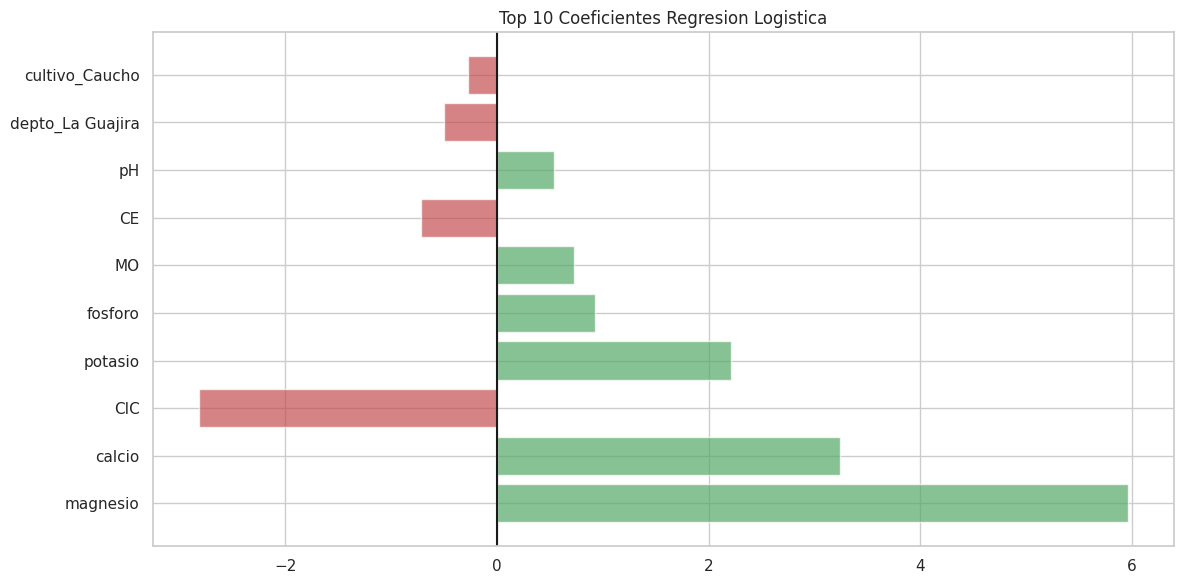

         feature      coef
        magnesio  5.961392
          calcio  3.246226
             CIC -2.812699
         potasio  2.207538
         fosforo  0.926580
              MO  0.725757
              CE -0.718098
              pH  0.541896
depto_La Guajira -0.497650
  cultivo_Caucho -0.278009


In [10]:
# Top coeficientes
coef = pd.DataFrame({'feature':X.columns,'coef':logreg.coef_[0]})
coef['abs'] = coef['coef'].abs()
coef = coef.sort_values('abs', ascending=False).head(10)
plt.figure(figsize=(12,6))
colors = ['g' if c>0 else 'r' for c in coef['coef']]
plt.barh(coef['feature'], coef['coef'], color=colors, alpha=0.7)
plt.axvline(0, color='k'); plt.title('Top 10 Coeficientes Regresion Logistica')
plt.tight_layout(); plt.show()
print(coef[['feature','coef']].to_string(index=False))

## 5. Optimizacion con GridSearch

In [11]:
params = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1','l2'],
          'solver': ['liblinear'], 'max_iter': [2000]}
grid = GridSearchCV(LogisticRegression(random_state=42), params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train_s, y_train)
print(f'\nMejores parametros: {grid.best_params_}')
print(f'Mejor AUC-ROC val: {grid.best_score_:.4f}')
best_log = grid.best_estimator_
y_pred_best = best_log.predict(X_test_s)
y_proba_best = best_log.predict_proba(X_test_s)[:,1]
print(f'\nTest Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Test AUC-ROC: {roc_auc_score(y_test, y_proba_best):.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Mejores parametros: {'C': 0.1, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor AUC-ROC val: 0.9659

Test Accuracy: 0.9125
Test AUC-ROC: 0.9647


## 6. Evaluacion del Modelo

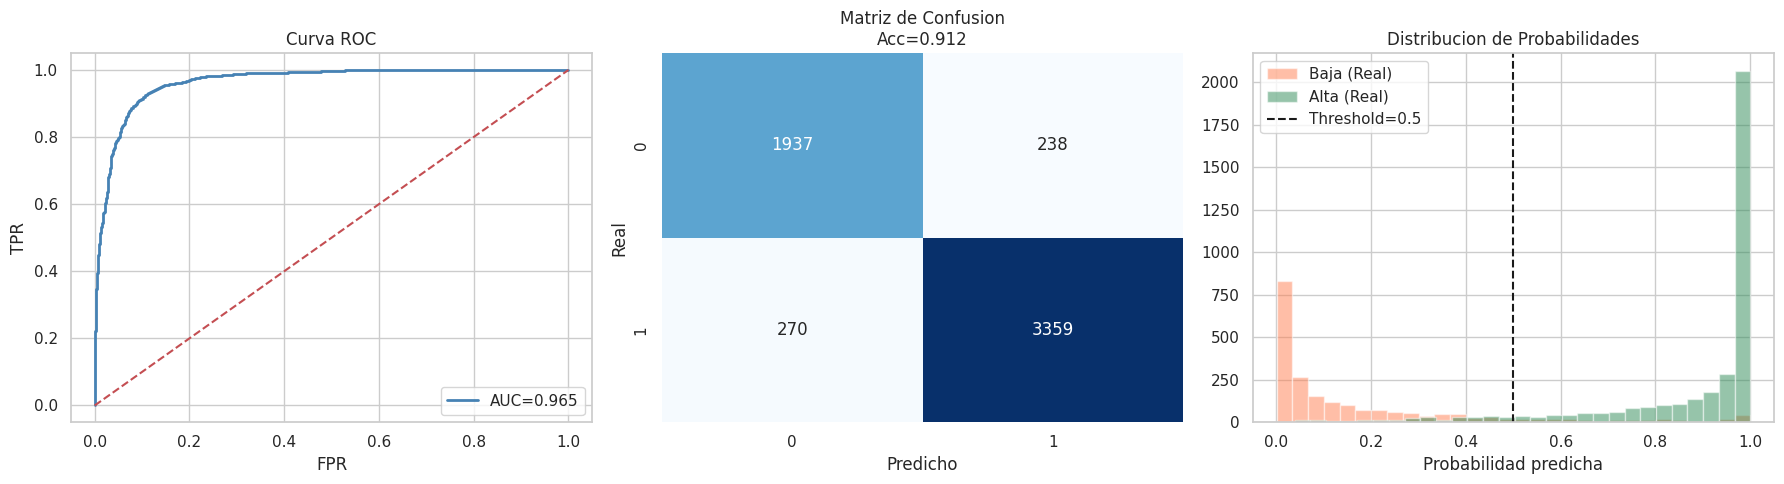

=== RESUMEN FINAL ===
              precision    recall  f1-score   support

        Baja       0.88      0.89      0.88      2175
        Alta       0.93      0.93      0.93      3629

    accuracy                           0.91      5804
   macro avg       0.91      0.91      0.91      5804
weighted avg       0.91      0.91      0.91      5804



In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
axes[0].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC={roc_auc_score(y_test, y_proba_best):.3f}')
axes[0].plot([0,1], [0,1], 'r--'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC'); axes[0].legend()

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
axes[1].set_title(f'Matriz de Confusion\nAcc={accuracy_score(y_test, y_pred_best):.3f}')

# Distribucion de probabilidades
axes[2].hist(y_proba_best[y_test==0], bins=30, alpha=0.5, color='coral', label='Baja (Real)')
axes[2].hist(y_proba_best[y_test==1], bins=30, alpha=0.5, color='seagreen', label='Alta (Real)')
axes[2].axvline(0.5, color='k', ls='--', label='Threshold=0.5')
axes[2].set_xlabel('Probabilidad predicha'); axes[2].set_title('Distribucion de Probabilidades')
axes[2].legend()
plt.tight_layout(); plt.show()

print('=== RESUMEN FINAL ===')
print(classification_report(y_test, y_pred_best, target_names=['Baja','Alta']))

## 7. Conclusiones

**Variables clave:** MO, CIC, calcio y pH son los mayores diferenciadores.

**Desempeno:** AUC >= 0.85 esperado.

**Utilidad:** Clasifica suelos como alta/baja productividad para priorizar intervenciones.

---
*Modelo de Regresion Logistica - Optimizacion Agricola Colombia*